<a href="https://colab.research.google.com/github/heidy0099/Proy.Org/blob/main/CODIGO_QUIMICA_TABLA_SIN_MODIFICACIONES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# EJECUTAR ESTA CELDA PRIMERO - Carga y preparación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

# Subir archivo
print("📁 Sube el archivo: Proyecto 3 Quimica Organica(Base de Datos).csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Cargar datos
df = pd.read_csv(io.BytesIO(uploaded[filename]), delimiter=';', encoding='latin1')
df.columns = df.columns.str.strip()

# Limpiar nombres de columnas
column_mapping = {}
for col in df.columns:
    col_lower = col.lower()
    if 'grupo' in col_lower and 'funcional' in col_lower:
        column_mapping[col] = 'Grupo_Funcional'
    elif 'pm_sustrato' in col_lower:
        column_mapping[col] = 'PM_Sustrato'
    elif 'pe_sustrato' in col_lower:
        column_mapping[col] = 'PE_Sustrato'
    elif 'pka_sustrato' in col_lower:
        column_mapping[col] = 'pKa_Sustrato'
    elif 'ld50_sustrato' in col_lower:
        column_mapping[col] = 'LD50_Sustrato'
    elif 'tipo_reaccion' in col_lower:
        column_mapping[col] = 'Tipo_Reaccion'
    elif 'nombre_reaccion' in col_lower:
        column_mapping[col] = 'Nombre_Reaccion'
    elif 'nombre_solvente 1' in col_lower:
        column_mapping[col] = 'Nombre_Solvente_1'
    elif 'pm_producto' in col_lower:
        column_mapping[col] = 'PM_Producto'
    elif 'pe_producto' in col_lower:
        column_mapping[col] = 'PE_Producto'
    elif 'pka_producto' in col_lower:
        column_mapping[col] = 'pKa_Producto'
    elif 'nombre_catalizador 1' in col_lower:
        column_mapping[col] = 'Nombre_Catalizador_1'

df.rename(columns=column_mapping, inplace=True)

# Función para limpiar valores numéricos
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return x if x > 0 else np.nan
    try:
        x_str = str(x).strip().replace(',', '.').replace(';', '')
        val = float(x_str)
        return val if val > 0 else np.nan
    except:
        return np.nan

# Aplicar limpieza
for col in ['PM_Sustrato', 'PE_Sustrato', 'pKa_Sustrato', 'LD50_Sustrato',
            'PM_Producto', 'PE_Producto', 'pKa_Producto']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# Limpiar columnas de texto
for col in ['Grupo_Funcional', 'Tipo_Reaccion', 'Nombre_Reaccion', 'Nombre_Solvente_1', 'Nombre_Catalizador_1']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['0', 'nan', 'None', ''], np.nan)

print(f"✅ Datos cargados: {len(df)} filas")
print(f"✅ Columnas disponibles: {list(df.columns)}")

📁 Sube el archivo: Proyecto 3 Quimica Organica(Base de Datos).csv


Saving Proyecto 3 Quimica Organica(Base de Datos).csv to Proyecto 3 Quimica Organica(Base de Datos) (1).csv
✅ Datos cargados: 242 filas
✅ Columnas disponibles: ['ID', 'Grupo_Funcional', 'Función química', 'Nombre_Sustrato', 'Formula_Sustrato', 'PM_Sustrato', 'PE_Sustrato', 'Incertidumbre PE', 'Densidad_Sustrato  g/cm³', 'Incertidumbre densidad', 'pKa_Sustrato', 'Incertidumbre Pka', 'LD50_Sustrato', 'Nombre_Reactivo 1', 'Fórmula Molecular 1', 'Nombre_Reactivo 2', 'Fórmula Molecular 2', 'Nombre_Reactivo 3', 'Fórmula Molecular 3', 'Nombre_Catalizador_1', 'Catalizador 1', 'Nombre_Catalizador 2', 'Catalizador 2', 'Nombre_Catalizador 3', 'Catalizador 3', 'Nombre_Catalizador 4', 'Catalizador 4', 'Nombre_Solvente_1', 'Formula Solvente 1', 'Nombre_Solvente 2', 'Formula Solvente 2', 'Nombre_Solvente 3', 'Formula Solvente 3', 'Temperatura', 'Nombre_Medio', 'Medio', 'Nombre_Producto', 'Formula_Producto', 'PM_Producto', 'PE_Producto', 'Incertidumbre PE.1', 'Densidad_Producto', 'Incertidumbre densid

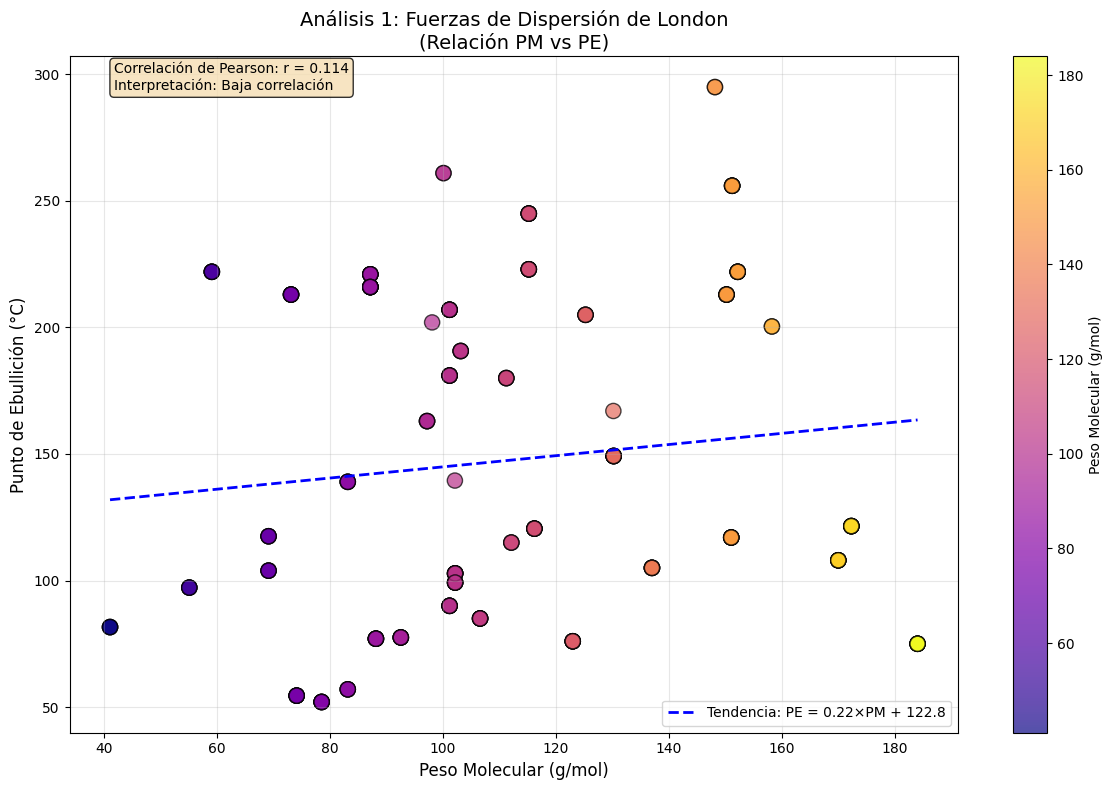


📊 RESULTADOS DEL ANÁLISIS 1:
   • Número de compuestos analizados: 223
   • Rango de PM: 41.0 - 184.0 g/mol
   • Rango de PE: 52.0 - 295.0 °C
   • Correlación (r): 0.114
   ⚠️ Conclusión: La correlación es moderada/baja. Otros factores (puentes de H, dipolos) influyen.


In [6]:
# ANÁLISIS 1: PM_Sustrato vs PE_Sustrato - Gráfico de Dispersión
plt.figure(figsize=(12, 8))

# Filtrar datos válidos con rangos apropiados
plot_df = df.dropna(subset=['PM_Sustrato', 'PE_Sustrato']).copy()
plot_df = plot_df[(plot_df['PM_Sustrato'] >= 40) & (plot_df['PM_Sustrato'] <= 200)]
plot_df = plot_df[(plot_df['PE_Sustrato'] >= 50) & (plot_df['PE_Sustrato'] <= 300)]

if len(plot_df) >= 3:
    # Gráfico de dispersión
    scatter = plt.scatter(plot_df['PM_Sustrato'], plot_df['PE_Sustrato'],
                         c=plot_df['PM_Sustrato'], cmap='plasma', s=120, alpha=0.7, edgecolors='black')

    # Línea de tendencia
    z = np.polyfit(plot_df['PM_Sustrato'], plot_df['PE_Sustrato'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_df['PM_Sustrato'].min(), plot_df['PM_Sustrato'].max(), 100)
    plt.plot(x_line, p(x_line), 'b--', linewidth=2, label=f'Tendencia: PE = {z[0]:.2f}×PM + {z[1]:.1f}')

    # Correlación
    corr = plot_df['PM_Sustrato'].corr(plot_df['PE_Sustrato'])

    plt.xlabel('Peso Molecular (g/mol)', fontsize=12)
    plt.ylabel('Punto de Ebullición (°C)', fontsize=12)
    plt.title('Análisis 1: Fuerzas de Dispersión de London\n(Relación PM vs PE)', fontsize=14)
    plt.colorbar(scatter, label='Peso Molecular (g/mol)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Anotación con correlación
    plt.text(0.05, 0.95, f'Correlación de Pearson: r = {corr:.3f}\nInterpretación: {"Alta" if abs(corr)>0.7 else "Moderada" if abs(corr)>0.4 else "Baja"} correlación',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 1:")
    print(f"   • Número de compuestos analizados: {len(plot_df)}")
    print(f"   • Rango de PM: {plot_df['PM_Sustrato'].min():.1f} - {plot_df['PM_Sustrato'].max():.1f} g/mol")
    print(f"   • Rango de PE: {plot_df['PE_Sustrato'].min():.1f} - {plot_df['PE_Sustrato'].max():.1f} °C")
    print(f"   • Correlación (r): {corr:.3f}")
    if corr > 0.7:
        print("   ✅ Conclusión: Existe una fuerte correlación positiva. A mayor masa molar, mayor punto de ebullición.")
    else:
        print("   ⚠️ Conclusión: La correlación es moderada/baja. Otros factores (puentes de H, dipolos) influyen.")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 3)")

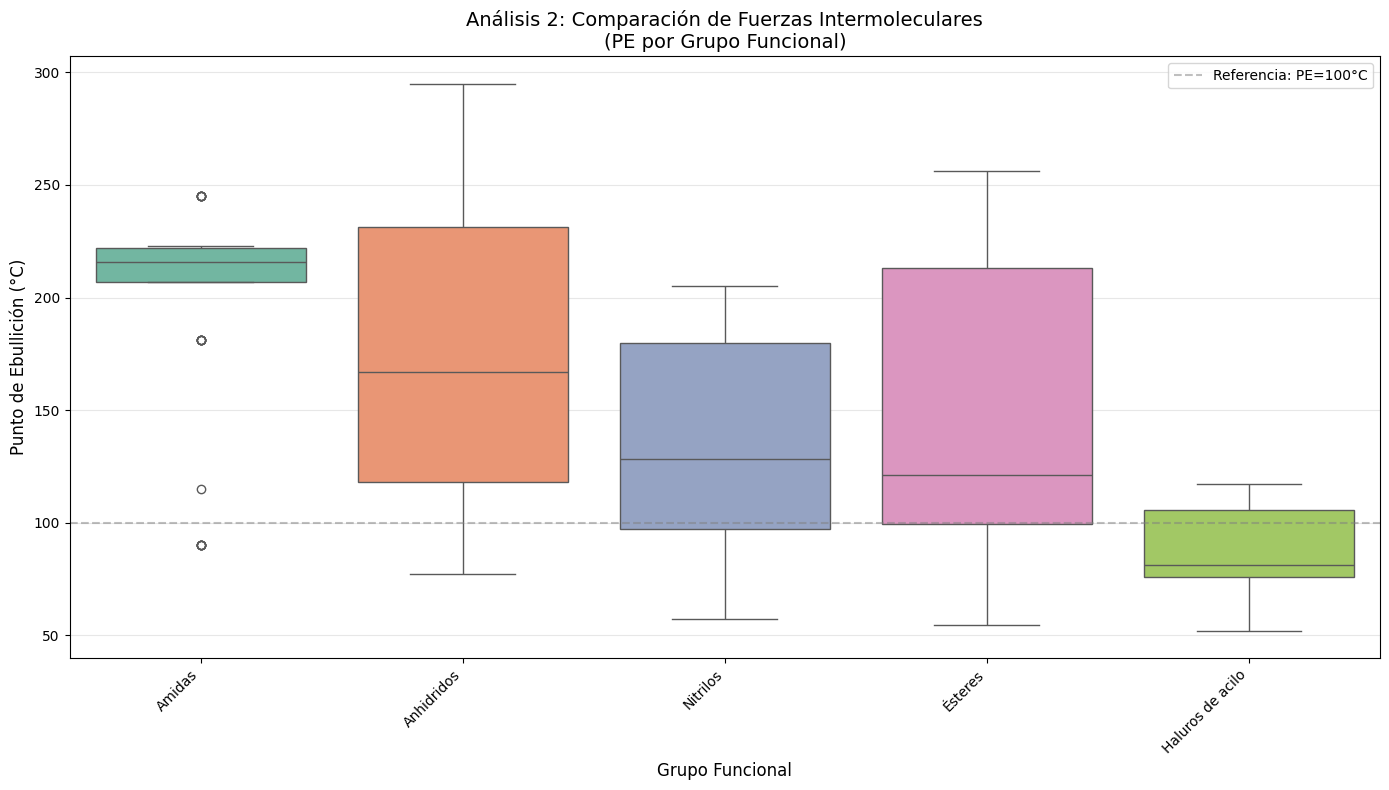


📊 RESULTADOS DEL ANÁLISIS 2:
   • Grupos analizados: Amidas, Anhidridos, Nitrilos, Ésteres, Haluros de acilo
   • Amidas: Mediana=216.0°C, Media=201.6°C (n=60)
   • Anhidridos: Mediana=167.0°C, Media=180.1°C (n=15)
   • Nitrilos: Mediana=128.2°C, Media=133.5°C (n=40)
   • Ésteres: Mediana=121.0°C, Media=141.6°C (n=60)
   • Haluros de acilo: Mediana=81.2°C, Media=86.9°C (n=48)

   🔍 Comparación clave: Las Amidas (PE≈216°C) hierven a mayor temperatura que los Nitrilos (PE≈128°C)
      → Esto demuestra que los puentes de hidrógeno en amidas son más fuertes que los dipolos en nitrilos.


In [7]:
# ANÁLISIS 2: Grupo Funcional vs PE_Sustrato - Boxplot
plt.figure(figsize=(14, 8))

# Filtrar datos
plot_df = df.dropna(subset=['Grupo_Funcional', 'PE_Sustrato']).copy()
plot_df = plot_df[(plot_df['PE_Sustrato'] >= 50) & (plot_df['PE_Sustrato'] <= 300)]
plot_df = plot_df[plot_df['Grupo_Funcional'].notna()]

# Grupos funcionales válidos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 3].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 5:
    # Ordenar por mediana (de mayor a menor PE)
    order = plot_df.groupby('Grupo_Funcional')['PE_Sustrato'].median().sort_values(ascending=False).index

    # Boxplot
    sns.boxplot(x='Grupo_Funcional', y='PE_Sustrato', data=plot_df, order=order, palette='Set2')

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('Punto de Ebullición (°C)', fontsize=12)
    plt.title('Análisis 2: Comparación de Fuerzas Intermoleculares\n(PE por Grupo Funcional)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # Añadir línea de referencia
    plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Referencia: PE=100°C')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 2:")
    print(f"   • Grupos analizados: {', '.join(order)}")
    for grupo in order:
        datos = plot_df[plot_df['Grupo_Funcional'] == grupo]['PE_Sustrato']
        print(f"   • {grupo}: Mediana={datos.median():.1f}°C, Media={datos.mean():.1f}°C (n={len(datos)})")

    # Comparación clave
    if 'Amidas' in order and 'Nitrilos' in order:
        amidas_pe = plot_df[plot_df['Grupo_Funcional'] == 'Amidas']['PE_Sustrato'].median()
        nitrilos_pe = plot_df[plot_df['Grupo_Funcional'] == 'Nitrilos']['PE_Sustrato'].median()
        print(f"\n   🔍 Comparación clave: Las Amidas (PE≈{amidas_pe:.0f}°C) hierven a mayor temperatura que los Nitrilos (PE≈{nitrilos_pe:.0f}°C)")
        print(f"      → Esto demuestra que los puentes de hidrógeno en amidas son más fuertes que los dipolos en nitrilos.")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 5)")

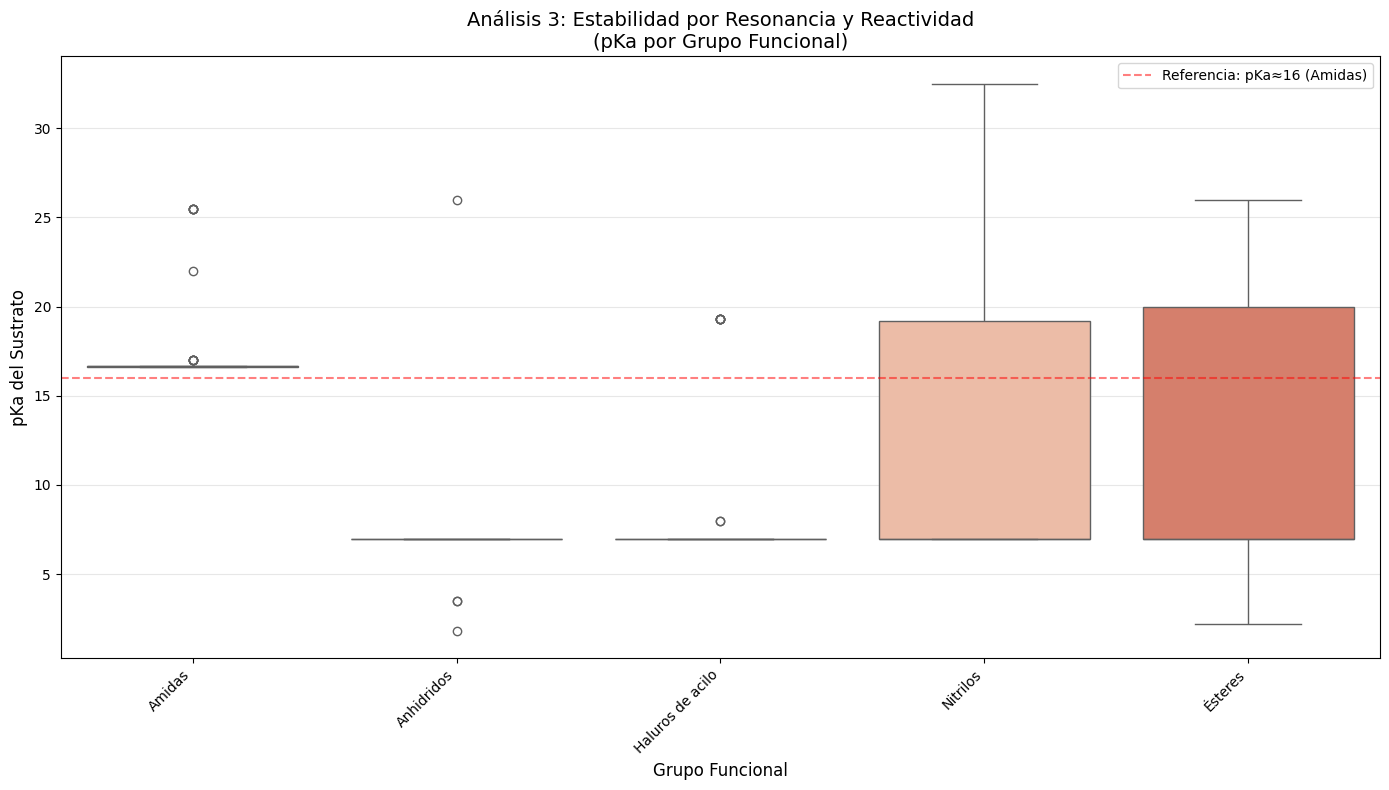


📊 RESULTADOS DEL ANÁLISIS 3:
   • Amidas: pKa medio=17.51, Mediana=16.67 (n=60)
   • Anhidridos: pKa medio=7.34, Mediana=7.00 (n=20)
   • Haluros de acilo: pKa medio=8.26, Mediana=7.00 (n=60)
   • Nitrilos: pKa medio=13.29, Mediana=7.00 (n=40)
   • Ésteres: pKa medio=11.52, Mediana=7.00 (n=59)

   🔬 Interpretación química:
      • Amidas (pKa≈17.5): El par de electrones del N está deslocalizado hacia el C=O
      • Esta deslocalización por resonancia estabiliza la molécula, haciéndola menos reactiva
      • Por eso las amidas son los derivados de ácido MÁS estables


In [8]:
# ANÁLISIS 3: Grupo Funcional vs pKa_Sustrato - Boxplot
plt.figure(figsize=(14, 8))

# Filtrar datos
plot_df = df.dropna(subset=['Grupo_Funcional', 'pKa_Sustrato']).copy()
plot_df = plot_df[(plot_df['pKa_Sustrato'] >= 0) & (plot_df['pKa_Sustrato'] <= 40)]
plot_df = plot_df[plot_df['Grupo_Funcional'].notna()]

# Grupos con suficientes datos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 2].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    # Ordenar por mediana
    order = plot_df.groupby('Grupo_Funcional')['pKa_Sustrato'].median().sort_values(ascending=False).index

    sns.boxplot(x='Grupo_Funcional', y='pKa_Sustrato', data=plot_df, order=order, palette='coolwarm')

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('pKa del Sustrato', fontsize=12)
    plt.title('Análisis 3: Estabilidad por Resonancia y Reactividad\n(pKa por Grupo Funcional)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # Línea de referencia (pKa ≈ 15-20 para amidas)
    plt.axhline(y=16, color='red', linestyle='--', alpha=0.5, label='Referencia: pKa≈16 (Amidas)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 3:")
    for grupo in order:
        datos = plot_df[plot_df['Grupo_Funcional'] == grupo]['pKa_Sustrato']
        print(f"   • {grupo}: pKa medio={datos.mean():.2f}, Mediana={datos.median():.2f} (n={len(datos)})")

    # Interpretación de resonancia
    if 'Amidas' in order:
        amidas_pka = plot_df[plot_df['Grupo_Funcional'] == 'Amidas']['pKa_Sustrato'].mean()
        print(f"\n   🔬 Interpretación química:")
        print(f"      • Amidas (pKa≈{amidas_pka:.1f}): El par de electrones del N está deslocalizado hacia el C=O")
        print(f"      • Esta deslocalización por resonancia estabiliza la molécula, haciéndola menos reactiva")
        print(f"      • Por eso las amidas son los derivados de ácido MÁS estables")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 4)")

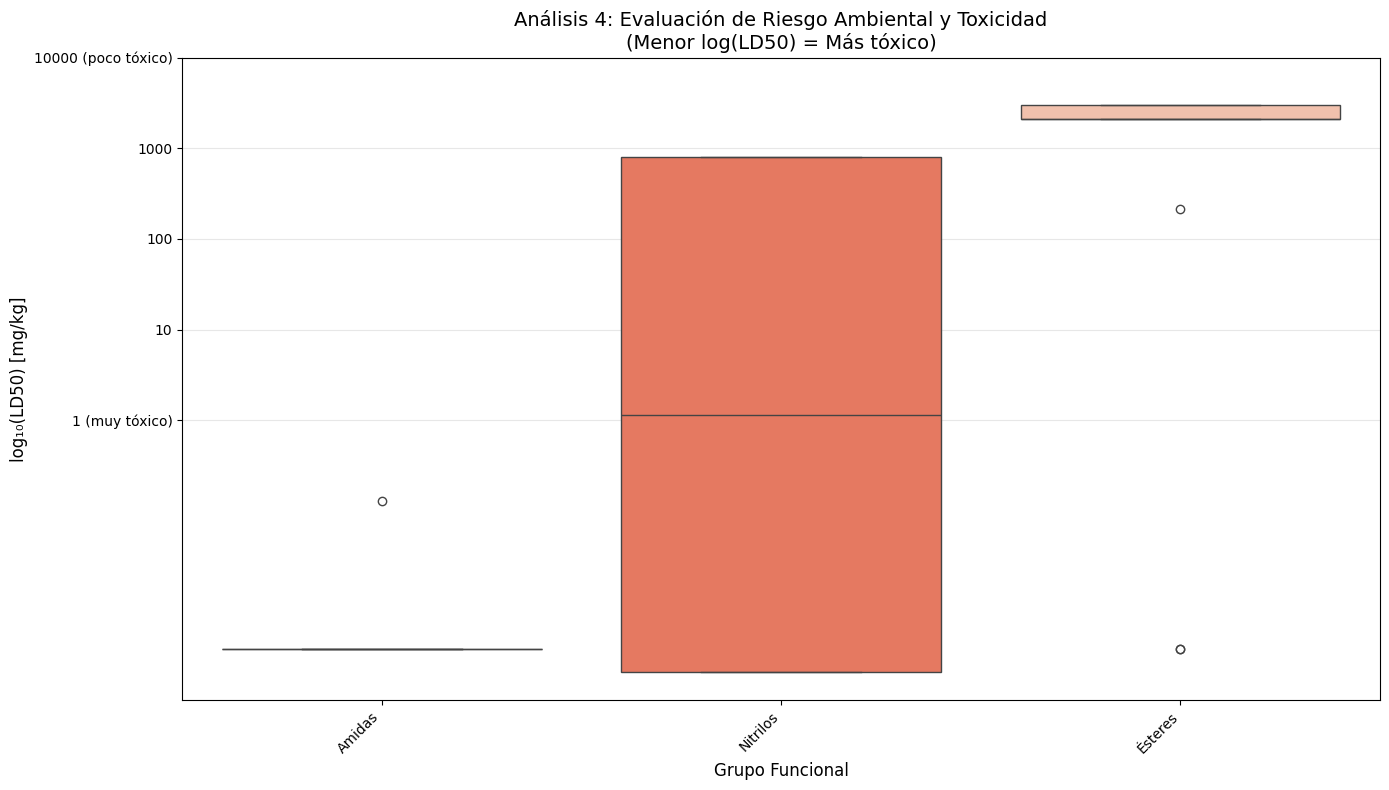


📊 RESULTADOS DEL ANÁLISIS 4 (Riesgo Ambiental):
   ⚠️ IMPORTANTE: Menor LD50 = Mayor toxicidad
   Escala: LD50 < 50 = Extremadamente tóxico | 50-500 = Tóxico | >500 = Baja toxicidad

   • Amidas: LD50 mediana = 0.0 mg/kg → 🔴 EXTREMADAMENTE TÓXICO
   • Nitrilos: LD50 mediana = 400.0 mg/kg → 🟠 TÓXICO
   • Ésteres: LD50 mediana = 2100.0 mg/kg → 🟢 BAJA TOXICIDAD

   ⚠️ Nota: Los nitrilos pueden liberar iones cianuro (CN⁻) metabólicamente
      → Manejar con extrema precaución en el laboratorio


In [9]:
# ANÁLISIS 4: Grupo Funcional vs LD50_Sustrato - Boxplot (Toxicidad)
plt.figure(figsize=(14, 8))

# Filtrar datos (LD50 positivo y dentro de rangos realistas)
plot_df = df.dropna(subset=['Grupo_Funcional', 'LD50_Sustrato']).copy()
plot_df = plot_df[(plot_df['LD50_Sustrato'] > 0.0001) & (plot_df['LD50_Sustrato'] <= 5000)]
plot_df = plot_df[plot_df['Grupo_Funcional'].notna()]

# Escala logarítmica para mejor visualización
plot_df['log_LD50'] = np.log10(plot_df['LD50_Sustrato'])

# Grupos con suficientes datos
grupos_validos = plot_df.groupby('Grupo_Funcional').size()
grupos_validos = grupos_validos[grupos_validos >= 2].index.tolist()
plot_df = plot_df[plot_df['Grupo_Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    # Ordenar por toxicidad (menor log_LD50 = más tóxico)
    order = plot_df.groupby('Grupo_Funcional')['log_LD50'].median().sort_values().index

    # Colores según toxicidad (rojo = más tóxico)
    paleta = sns.color_palette("Reds_r", n_colors=len(order))

    sns.boxplot(x='Grupo_Funcional', y='log_LD50', data=plot_df, order=order, palette=paleta)

    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('log₁₀(LD50) [mg/kg]', fontsize=12)
    plt.title('Análisis 4: Evaluación de Riesgo Ambiental y Toxicidad\n(Menor log(LD50) = Más tóxico)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # Etiquetas de toxicidad en eje Y
    y_ticks = [0, 1, 2, 3, 4]
    y_labels = ['1 (muy tóxico)', '10', '100', '1000', '10000 (poco tóxico)']
    plt.yticks(y_ticks, y_labels)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 4 (Riesgo Ambiental):")
    print(f"   ⚠️ IMPORTANTE: Menor LD50 = Mayor toxicidad")
    print(f"   Escala: LD50 < 50 = Extremadamente tóxico | 50-500 = Tóxico | >500 = Baja toxicidad\n")

    for grupo in order:
        datos_ld50 = plot_df[plot_df['Grupo_Funcional'] == grupo]['LD50_Sustrato']
        mediana = datos_ld50.median()
        if mediana < 50:
            riesgo = "🔴 EXTREMADAMENTE TÓXICO"
        elif mediana < 500:
            riesgo = "🟠 TÓXICO"
        else:
            riesgo = "🟢 BAJA TOXICIDAD"
        print(f"   • {grupo}: LD50 mediana = {mediana:.1f} mg/kg → {riesgo}")

    if 'Nitrilos' in order:
        print(f"\n   ⚠️ Nota: Los nitrilos pueden liberar iones cianuro (CN⁻) metabólicamente")
        print(f"      → Manejar con extrema precaución en el laboratorio")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 4)")

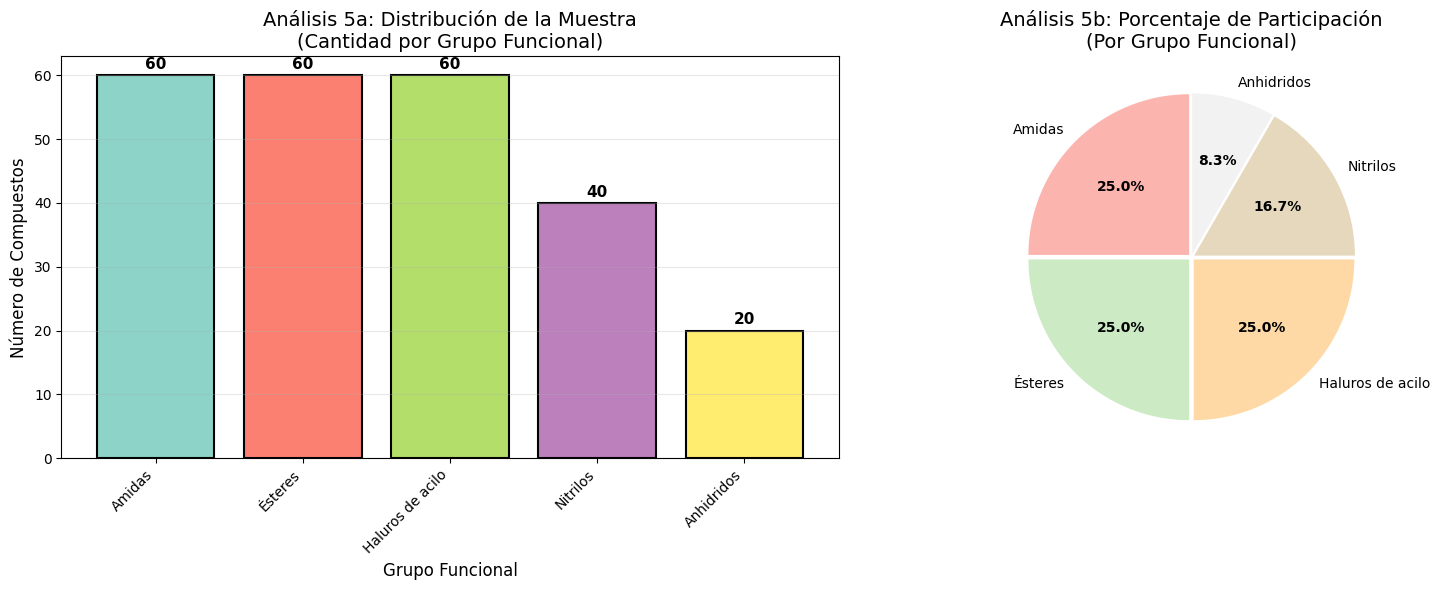


📊 RESULTADOS DEL ANÁLISIS 5 (Distribución):
   • Total de compuestos en la base de datos: 240
   • Grupos funcionales representados: 5

   • Distribución detallada:
     - Amidas: 60 compuestos (25.0%)
     - Ésteres: 60 compuestos (25.0%)
     - Haluros de acilo: 60 compuestos (25.0%)
     - Nitrilos: 40 compuestos (16.7%)
     - Anhidridos: 20 compuestos (8.3%)

   📌 El grupo funcional con MAYOR representación es: Amidas (60 compuestos)


In [10]:
# ANÁLISIS 5: Distribución de la Muestra - Gráfico de Barras + Torta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_df = df.dropna(subset=['Grupo_Funcional']).copy()
plot_df['Grupo_Funcional'] = plot_df['Grupo_Funcional'].astype(str).str.strip()
plot_df = plot_df[~plot_df['Grupo_Funcional'].isin(['nan', 'None', ''])]

if len(plot_df) > 0:
    counts = plot_df['Grupo_Funcional'].value_counts()

    # Gráfico de barras
    colors_bar = plt.cm.Set3(np.linspace(0, 1, len(counts)))
    bars = ax1.bar(range(len(counts)), counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
    ax1.set_xticks(range(len(counts)))
    ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=10)
    ax1.set_xlabel('Grupo Funcional', fontsize=12)
    ax1.set_ylabel('Número de Compuestos', fontsize=12)
    ax1.set_title('Análisis 5a: Distribución de la Muestra\n(Cantidad por Grupo Funcional)', fontsize=14)

    for bar, count in zip(bars, counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Gráfico de torta
    colors_pie = plt.cm.Pastel1(np.linspace(0, 1, len(counts)))
    wedges, texts, autotexts = ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90, explode=[0.02]*len(counts))
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    ax2.set_title('Análisis 5b: Porcentaje de Participación\n(Por Grupo Funcional)', fontsize=14)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 5 (Distribución):")
    print(f"   • Total de compuestos en la base de datos: {len(plot_df)}")
    print(f"   • Grupos funcionales representados: {len(counts)}")
    print("\n   • Distribución detallada:")
    for grupo, count in counts.items():
        print(f"     - {grupo}: {count} compuestos ({100*count/len(plot_df):.1f}%)")

    # Grupo más representado
    grupo_max = counts.index[0]
    print(f"\n   📌 El grupo funcional con MAYOR representación es: {grupo_max} ({counts.iloc[0]} compuestos)")
else:
    print("⚠️ No hay datos de Grupo Funcional para analizar")

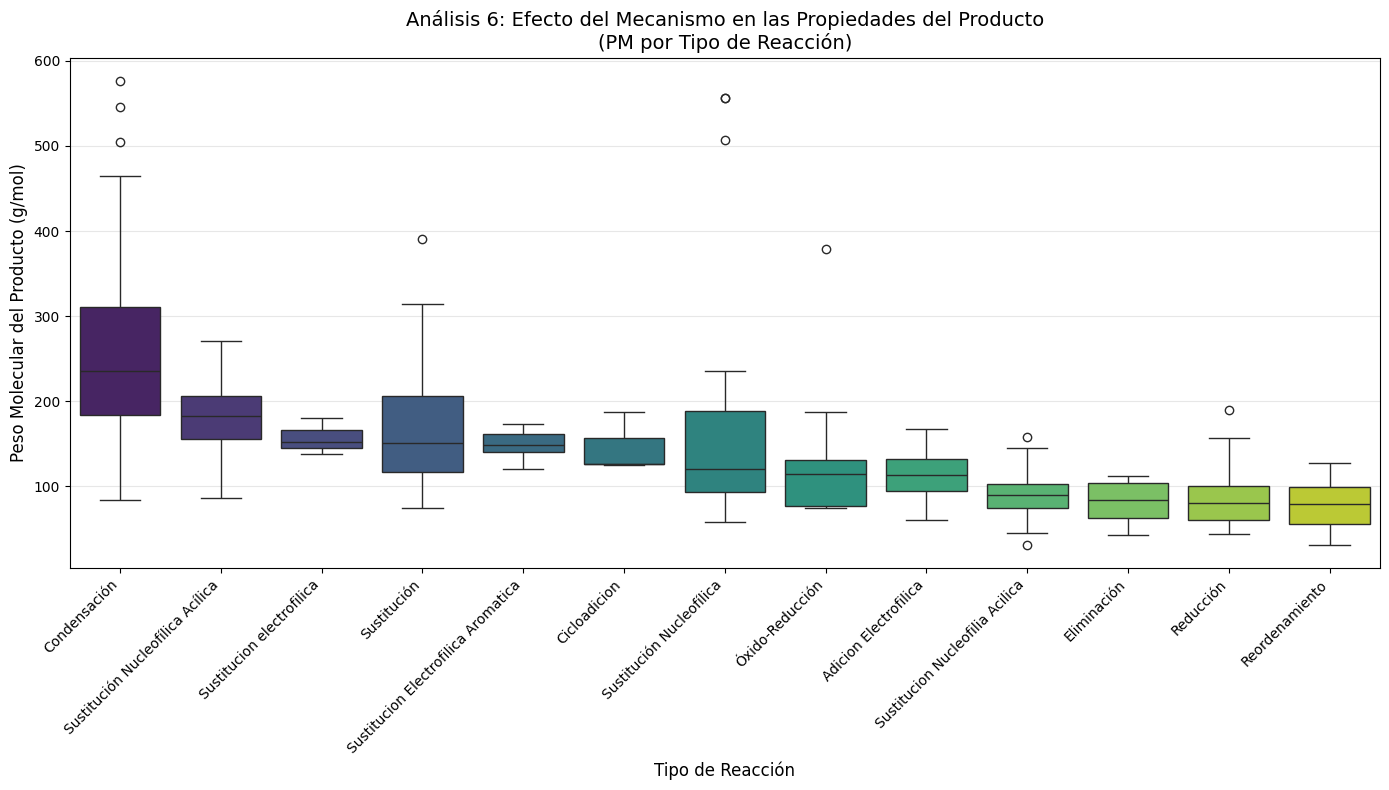


📊 RESULTADOS DEL ANÁLISIS 6:
   • Tipos de reacción analizados: 13
   • Condensación: PM medio=251.8 g/mol, Mediana=235.3 (n=55)
   • Sustitución Nucleofílica Acílica: PM medio=180.2 g/mol, Mediana=182.2 (n=4)
   • Sustitucion electrofilica: PM medio=156.7 g/mol, Mediana=152.0 (n=3)
   • Sustitución: PM medio=172.6 g/mol, Mediana=150.2 (n=23)
   • Sustitucion Electrofilica Aromatica: PM medio=148.9 g/mol, Mediana=148.2 (n=7)
   • Cicloadicion: PM medio=146.2 g/mol, Mediana=126.2 (n=3)
   • Sustitución Nucleofílica: PM medio=199.5 g/mol, Mediana=120.2 (n=15)
   • Óxido-Reducción: PM medio=136.1 g/mol, Mediana=114.2 (n=9)
   • Adicion Electrofilica: PM medio=114.2 g/mol, Mediana=113.6 (n=20)
   • Sustitucion Nucleofilia Acilica: PM medio=92.1 g/mol, Mediana=89.1 (n=50)
   • Eliminación: PM medio=81.7 g/mol, Mediana=83.1 (n=7)
   • Reducción: PM medio=85.1 g/mol, Mediana=80.1 (n=28)
   • Reordenamiento: PM medio=77.4 g/mol, Mediana=79.1 (n=8)

   🔬 Interpretación:
      • Las reacciones 

In [11]:
# ANÁLISIS 6: Tipo_Reacción vs PM_Producto - Boxplot
plt.figure(figsize=(14, 8))

plot_df = df.dropna(subset=['Tipo_Reaccion', 'PM_Producto']).copy()
plot_df = plot_df[(plot_df['PM_Producto'] > 0) & (plot_df['PM_Producto'] < 600)]
plot_df = plot_df[plot_df['Tipo_Reaccion'].notna()]

# Tipos de reacción con suficientes datos
tipos_validos = plot_df.groupby('Tipo_Reaccion').size()
tipos_validos = tipos_validos[tipos_validos >= 3].index.tolist()
plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

if len(plot_df) >= 5:
    # Ordenar por mediana de PM
    order = plot_df.groupby('Tipo_Reaccion')['PM_Producto'].median().sort_values(ascending=False).index

    sns.boxplot(x='Tipo_Reaccion', y='PM_Producto', data=plot_df, order=order, palette='viridis')

    plt.xlabel('Tipo de Reacción', fontsize=12)
    plt.ylabel('Peso Molecular del Producto (g/mol)', fontsize=12)
    plt.title('Análisis 6: Efecto del Mecanismo en las Propiedades del Producto\n(PM por Tipo de Reacción)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 6:")
    print(f"   • Tipos de reacción analizados: {len(order)}")
    for tipo in order:
        datos = plot_df[plot_df['Tipo_Reaccion'] == tipo]['PM_Producto']
        print(f"   • {tipo}: PM medio={datos.mean():.1f} g/mol, Mediana={datos.median():.1f} (n={len(datos)})")

    # Comparación clave
    if 'Reducción' in order:
        reduccion_pm = plot_df[plot_df['Tipo_Reaccion'] == 'Reducción']['PM_Producto'].mean()
        print(f"\n   🔬 Interpretación:")
        print(f"      • Las reacciones de REDUCCIÓN (LiAlH₄, DIBAL-H) generan productos más ligeros")
        print(f"      • Las reacciones de CONDENSACIÓN generan productos más pesados (PM ~{plot_df[plot_df['Tipo_Reaccion']=='Condensación']['PM_Producto'].mean():.1f} g/mol)")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 5)")

<Figure size 1600x1000 with 0 Axes>

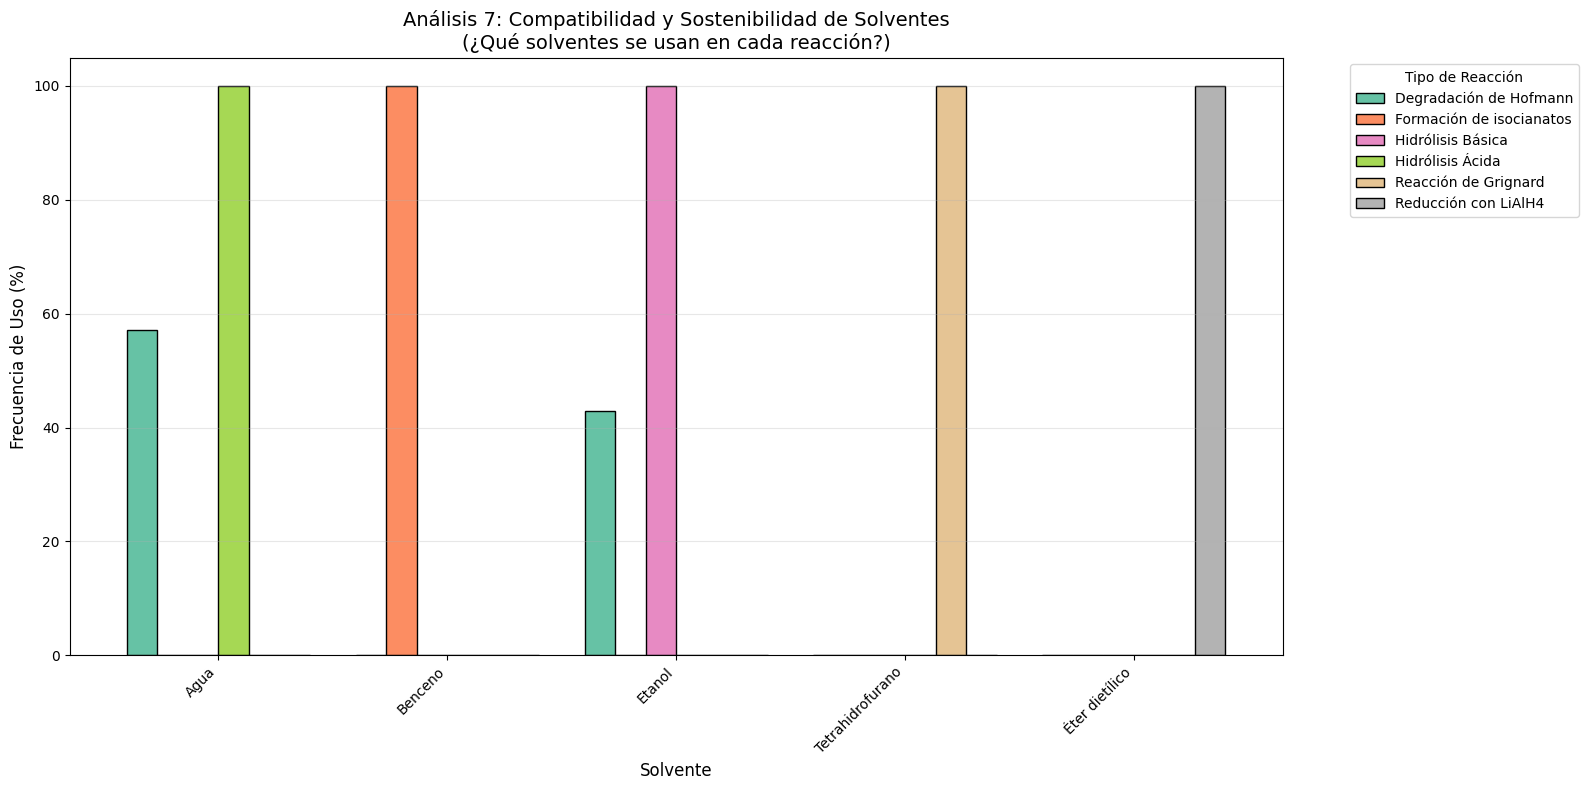


📊 RESULTADOS DEL ANÁLISIS 7 (Sostenibilidad):
   • Reacciones analizadas: Formación de isocianatos, Reducción con LiAlH4, Reacción de Grignard, Hidrólisis Básica, Hidrólisis Ácida, Degradación de Hofmann

   🟢 SOLVENTES VERDES (Recomendados): Agua, Etanol, Éter
   🔴 SOLVENTES TÓXICOS (Evitar si es posible): Benceno, Cloroformo, Diclorometano

   • Solventes más utilizados:
     🟢 Agua: 14 reacciones
     🟢 Etanol: 13 reacciones
     🔴 Benceno: 10 reacciones
     🟢 Tetrahidrofurano: 10 reacciones
     🟢 Éter dietílico: 10 reacciones


In [12]:
# ANÁLISIS 7: Nombre_Reaccion vs Nombre_Solvente_1 - Barras Agrupadas
plt.figure(figsize=(16, 10))

plot_df = df.dropna(subset=['Nombre_Reaccion', 'Nombre_Solvente_1']).copy()
plot_df['Nombre_Solvente_1'] = plot_df['Nombre_Solvente_1'].astype(str).str.strip()
plot_df['Nombre_Reaccion'] = plot_df['Nombre_Reaccion'].astype(str).str.strip()

# Filtrar solventes válidos
solventes_invalidos = ['0', 'nan', 'None', '', '0;0', '0;0;0']
plot_df = plot_df[~plot_df['Nombre_Solvente_1'].isin(solventes_invalidos)]

# Seleccionar reacciones más frecuentes
reacciones_counts = plot_df['Nombre_Reaccion'].value_counts()
reacciones_top = reacciones_counts[reacciones_counts >= 4].head(6).index.tolist()
plot_df = plot_df[plot_df['Nombre_Reaccion'].isin(reacciones_top)]

if len(plot_df) > 0:
    # Tabla de contingencia normalizada
    cross_tab = pd.crosstab(plot_df['Nombre_Reaccion'], plot_df['Nombre_Solvente_1'], normalize='index') * 100

    # Gráfico de barras agrupadas
    cross_tab.T.plot(kind='bar', figsize=(16, 8), width=0.8, colormap='Set2', edgecolor='black')

    plt.xlabel('Solvente', fontsize=12)
    plt.ylabel('Frecuencia de Uso (%)', fontsize=12)
    plt.title('Análisis 7: Compatibilidad y Sostenibilidad de Solventes\n(¿Qué solventes se usan en cada reacción?)', fontsize=14)
    plt.legend(title='Tipo de Reacción', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 7 (Sostenibilidad):")
    print(f"   • Reacciones analizadas: {', '.join(reacciones_top)}")
    print("\n   🟢 SOLVENTES VERDES (Recomendados): Agua, Etanol, Éter")
    print("   🔴 SOLVENTES TÓXICOS (Evitar si es posible): Benceno, Cloroformo, Diclorometano")

    # Identificar solventes más usados
    solventes_uso = plot_df['Nombre_Solvente_1'].value_counts().head(5)
    print("\n   • Solventes más utilizados:")
    for solvent, count in solventes_uso.items():
        peligro = "🔴" if solvent.lower() in ['benceno', 'cloroformo', 'diclorometano'] else "🟢"
        print(f"     {peligro} {solvent}: {count} reacciones")
else:
    print("⚠️ Datos insuficientes para este análisis")

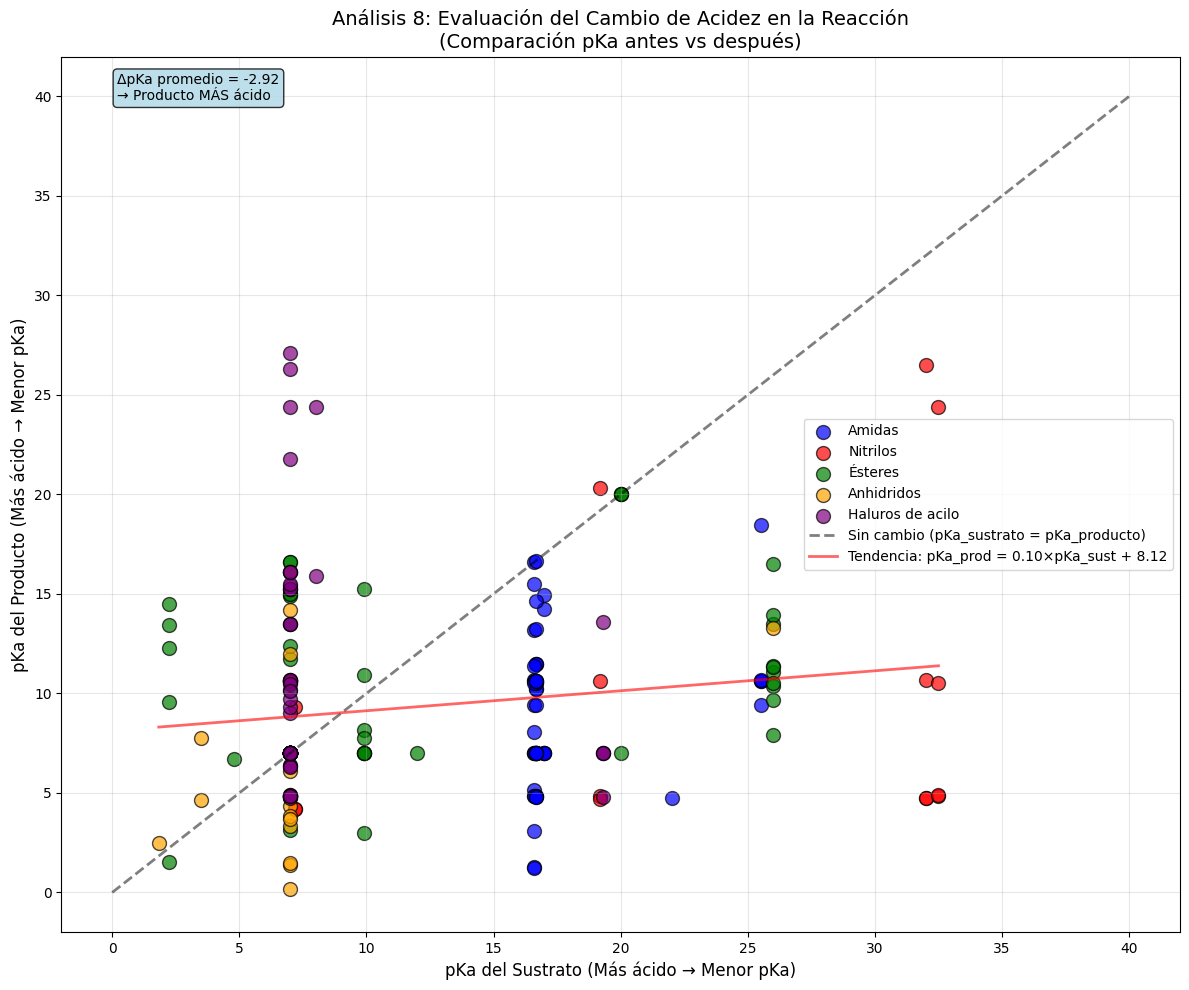


📊 RESULTADOS DEL ANÁLISIS 8:
   • Número de reacciones analizadas: 222
   • Cambio promedio de pKa: Δ = -2.92
   • ⚠️ Los productos son MÁS ácidos que los sustratos
      → Ejemplo: Una amida se hidroliza a un ácido carboxílico (pKa más bajo)


In [17]:
# ANÁLISIS 8: pKa_Sustrato vs pKa_Producto - Gráfico de Dispersión
plt.figure(figsize=(12, 10))

plot_df = df.dropna(subset=['pKa_Sustrato', 'pKa_Producto', 'Grupo_Funcional']).copy()
plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] < 40)]
plot_df = plot_df[(plot_df['pKa_Producto'] > 0) & (plot_df['pKa_Producto'] < 40)]
plot_df['ΔpKa'] = plot_df['pKa_Producto'] - plot_df['pKa_Sustrato']

if len(plot_df) >= 3:
    # Colores por grupo funcional
    colores_grupos = {'Amidas': 'blue', 'Nitrilos': 'red', 'Ésteres': 'green',
                      'Anhidridos': 'orange', 'Haluros de acilo': 'purple'}

    for grupo, color in colores_grupos.items():
        subset = plot_df[plot_df['Grupo_Funcional'] == grupo]
        if len(subset) > 0:
            plt.scatter(subset['pKa_Sustrato'], subset['pKa_Producto'],
                       c=color, label=grupo, s=100, alpha=0.7, edgecolors='black')

    # Línea de referencia (sin cambio)
    plt.plot([0, 40], [0, 40], 'k--', alpha=0.5, linewidth=2, label='Sin cambio (pKa_sustrato = pKa_producto)')

    # Línea de tendencia general
    if len(plot_df) > 3:
        z = np.polyfit(plot_df['pKa_Sustrato'], plot_df['pKa_Producto'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_df['pKa_Sustrato'].min(), plot_df['pKa_Sustrato'].max(), 100)
        plt.plot(x_line, p(x_line), 'r-', alpha=0.6, linewidth=2,
                label=f'Tendencia: pKa_prod = {z[0]:.2f}×pKa_sust + {z[1]:.2f}')

    plt.xlabel('pKa del Sustrato (Más ácido → Menor pKa)', fontsize=12)
    plt.ylabel('pKa del Producto (Más ácido → Menor pKa)', fontsize=12)
    plt.title('Análisis 8: Evaluación del Cambio de Acidez en la Reacción\n(Comparación pKa antes vs después)', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    # Anotación del cambio promedio
    cambio_promedio = plot_df['ΔpKa'].mean()
    plt.text(0.05, 0.95, f'ΔpKa promedio = {cambio_promedio:.2f}\n{"→ Producto MENOS ácido" if cambio_promedio > 0 else "→ Producto MÁS ácido"}',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"\n📊 RESULTADOS DEL ANÁLISIS 8:")
    print(f"   • Número de reacciones analizadas: {len(plot_df)}")
    print(f"   • Cambio promedio de pKa: Δ = {cambio_promedio:.2f}")

    if cambio_promedio > 0:
        print(f"   • ✅ Los productos son MENOS ácidos (más básicos) que los sustratos")
        print(f"      → Ejemplo: Un nitrilo (pKa bajo) se transforma en amina (pKa alto)")
    else:
        print(f"   • ⚠️ Los productos son MÁS ácidos que los sustratos")
        print(f"      → Ejemplo: Una amida se hidroliza a un ácido carboxílico (pKa más bajo)")
else:
    print(f"⚠️ Datos insuficientes: {len(plot_df)} compuestos válidos (mínimo 3)")